#**PROJECT BACKGROUND**

The hotel industry frequently faces challenges with booking cancellations, impacting revenue and operational efficiency. This project focuses on understanding and analyzing various factors that contribute to booking cancellations, utilizing data from hotel bookings to identify trends and patterns.

# **LEARN ABOUT DATA**

**Understanding the Columns:**
0.	hotel: Name of hotel (Categorical)
1.	is_canceled: Specifies whether the booking was canceled or not (0=not canceled, 1=canceled). (Binary)
2.	lead_time: Number of days between booking date and arrival date (Numeric)
3.	arrival_date_year: The year of the arrival date (Numeric)
4.	arrival_date_month: The month of the arrival date (Categorical)
5.	arrival_date_week_number: Specifies the week number in which guests arrived at the hotel. (Numeric)
6.	arrival_date_day_of_month: The day of the month of the arrival date (Numeric)
7.	stays_in_weekend_nights: Indicates how many nights (Saturday or Sunday) guests stayed or booked to stay at a hotel during weekends.  (Numeric)
8.	stays_in_week_nights: Represents how many weeknights (Monday to Friday) guests stayed or booked to stay at a hotel during weekdays. (Numeric)
9.	adults: Indicates the number of adults included in each booking. (Numerical)
10.	children: Indicates the number of children included in each booking. (Numerical)
11.	babies: Indicates the number of babies included in each booking. (Numerical)
12.	meal: Describes what type of meal was booked (Breakfast only, Half board, Full board, or Undefined/SC – no meal package). (Categorical)
13.	country: Denotes the country-of-origin for each guest who made a reservation. (Categorical)
14.	market_segment: Shows various market segments that individuals belong to when making reservations (e.g., Online Travel Agents, Offline Travel Agents, Corporate clients). (Categorical)
15.	distribution_channel: Specifies different channels through which bookings were made (e.g., online travel agencies, direct bookings with hotels/tour operators, corporate arrangements). (Categorical)
16.	is_repeated_guest: Indicates whether the guest is a repeated visitor (0=not repeated guest, 1=repeated guest). (Binary)
17.	previous_cancellations: Represents the number of times guests previously canceled their bookings. (Numerical)
18.	previous_bookings_not_canceled: Denotes the count of previous bookings made by guests that were not canceled. (Numerical)
19.	reserved_room_type: Identifies the type of room initially reserved. (Categorical)
20.	assigned_room_type: mentions which type room was finally assigned for each booking (Categorical).
21.	booking_changes: Represents the number of changes made to the booking. (Numerical)
22.	deposit_type: Indicates the type of deposit made for the booking. (Categorical)
23.	agent: Represents the ID of the travel agency that made the booking. (Categorical)
24.	company: Represents the ID of the company that made the booking. (Categorical)
25.	days_in_waiting_list: Represents the number of days the booking was on the waiting list before being confirmed. (Numerical).
26.	customer_type : Indicates the type of customer (e.g., transient, contract, group, or other). (Categorical)
27.	adr: Represents the average daily rate (price per room) for the booking. (Numerical)
28.	required_car_parking_spaces : Indicates the number of car parking spaces required by the guest. (Numerical)
29.	total_of_special_requests : Represents the total number of special requests made by the guest (e.g., extra bed, room amenities). (Numerical)
30.	reservation_status : Indicates the status of the reservation (e.g., canceled, checked-in, no-show). (Categorical)
31.	reservation_status_date : Represents the date on which the reservation status was last updated. (Date)
32.	Booking ID: Number Booking

# **IMPORT LIBRARIES**

In [ ]:
!pip install mljar-scikit-plot
!pip install dalex
!pip install shap
!pip install eli5
!pip install imblearn

  Preparing metadata (setup.py) ... done
  Created wheel for mljar-scikit-plot: filename=mljar_scikit_plot-0.3.12-py3-none-any.whl size=32012 sha256=cbdca259c5e39a66c73c340a5366e1fb3a47c8e78c95e620fafc0be111a4911d
  Stored in directory: /root/.cache/pip/wheels/f1/02/59/22b0e9bcc992a79df54193032d45720f9713bd3065617ef4a5
Successfully built mljar-scikit-plot
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for dalex: filename=dalex-1.7.0-py3-none-any.whl size=1042462 sha256=a8db9385da7647f889421eba7eb729ec6cbc4dbbed3bd6f174a1f6cf3f240abb
  Stored in directory: /root/.cache/pip/wheels/e2/38/c1/25a95206a4873a287d776fc8e77aa7d93971acc643ecb3db38
Successfully built dalex
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 24.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for eli5: filename=

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import sklearn.metrics as metrics
import scikitplot as skplt

import dalex as dx
import shap

from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error)
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


# PREPROCESSING

## Load Data

In [ ]:
df = pd.read_csv('hotel.csv')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,...,314.0,NaN,0,Transient,38.40,0,0,Check-Out,2019-01-14,1
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,...,1.0,NaN,0,Transient,62.80,0,0,Canceled,2017-10-21,2
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,...,12.0,NaN,0,Transient,110.00,0,0,Canceled,2018-11-25,3
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,...,NaN,200.0,0,Transient,45.00,0,0,Check-Out,2018-10-18,4
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,...,16.0,NaN,0,Transient,57.92,0,1,Canceled,2017-08-24,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83288,"Crystal Cove, Barbados Barbados",0,4,2018,October,44,25,0,2,2,...,9.0,NaN,0,Transient,169.00,1,1,Check-Out,2018-10-27,83289
83289,"Berlin Marriott Hotel Berlin, Germany",0,30,2017,September,38,14,1,3,2,...,9.0,NaN,0,Transient,94.50,0,2,Check-Out,2017-09-18,83290
83290,"The Ritz-Carlton, Tokyo Tokyo, Japan",0,165,2019,June,25,21,4,10,2,...,NaN,NaN,0,Transient,123.50,0,1,Check-Out,2019-07-05,83291
83291,"Colony Club, Barbados Barbados",0,180,2018,July,32,31,2,4,2,...,9.0,NaN,0,Transient,122.25,0,1,Check-Out,2018-08-06,83292


## Data Information

In [ ]:
df.shape

(83293, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83290 non-null  float64
 11  babies                          83293 non-null  int64  
 12  meal                            

## Data Cleaning

### Duplicated Values

In [ ]:
df.duplicated().sum()

0

### Missing Value

In [ ]:
df.isnull().sum().sort_values(ascending=False)[:10]

,0
company,78559
agent,11404
country,346
children,3
hotel,0
assigned_room_type,0
booking_changes,0
deposit_type,0
days_in_waiting_list,0
previous_bookings_not_canceled,0


In [ ]:
df_missing_value = df.isnull().sum().reset_index()
df_missing_value.columns = ['feature','missing_value']
df_missing_value['percentage'] = round((df_missing_value['missing_value']/len(df))*100,2)
df_missing_value = df_missing_value.sort_values('missing_value', ascending=False).reset_index(drop=True)
df_missing_value

,feature,missing_value,percentage
0,company,78559,94.32
1,agent,11404,13.69
2,country,346,0.42
3,children,3,0.00
4,hotel,0,0.00
5,assigned_room_type,0,0.00
6,booking_changes,0,0.00
7,deposit_type,0,0.00
8,days_in_waiting_list,0,0.00
9,previous_bookings_not_canceled,0,0.00


<ipython-input-9-da53c0a36fcd>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(x = 'feature',y='percentage',data=df_missing_value.head(4),ax=ax,
<ipython-input-9-da53c0a36fcd>:3: UserWarning: The palette list has more values (7) than needed (4), which may not be intended.
  g = sns.barplot(x = 'feature',y='percentage',data=df_missing_value.head(4),ax=ax,
<ipython-input-9-da53c0a36fcd>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=0)


<function matplotlib.pyplot.tight_layout(*, pad=1.08, h_pad=None, w_pad=None, rect=None)>

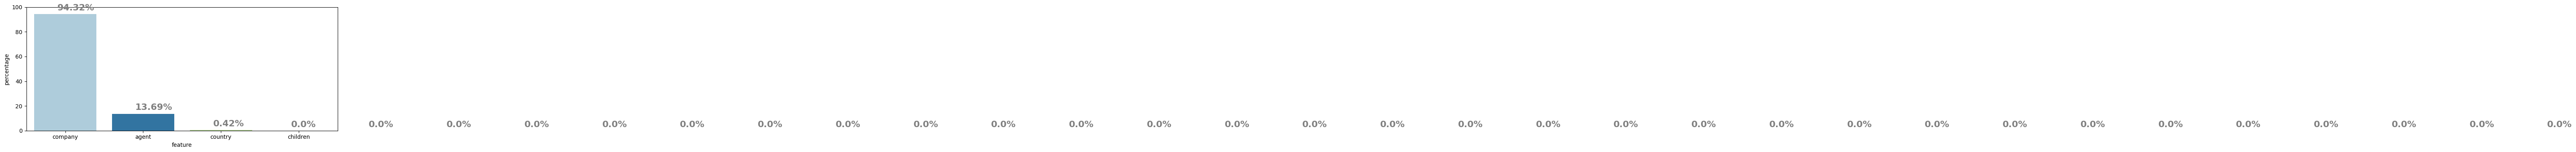

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))

g = sns.barplot(x = 'feature',y='percentage',data=df_missing_value.head(4),ax=ax,
               palette=sns.color_palette("Paired", n_colors=7, desat=1))

x = np.arange(len(df_missing_value['feature']))
y = df_missing_value['percentage']

for i, v in enumerate(y):
    ax.text(x[i]- 0.1, v+3, str(v)+'%', fontsize = 16, color='grey', fontweight='bold')

ax.set_ylim(0,100)

ax.set_xticklabels(ax.get_xticklabels(),rotation=0)
plt.tight_layout

#### Handling Missing Value

In [ ]:
# # Dropping the 'company' column due to a high percentage of missing values (94.32%)

df=df.drop(['company'],axis=1)

In [ ]:
# Filling NaN values in the 'agent' column with 0, assuming no booking was made through an agent
df['agent'] = df['agent'].fillna(0)
df['agent']

,agent
0,314.0
1,1.0
2,12.0
3,0.0
4,16.0
...,...
83288,9.0
83289,9.0
83290,0.0
83291,9.0


In [ ]:
# The 'Country' column is categorical, so we use the mode: the most frequently occurring value in the column

df['country'] = df['country'].fillna(df['country'].mode()[0])

In [ ]:
# In the 'children' column, since the percentage of missing values is very small (< 1%), imputation is done with the assumption that there are no children, filling NaN with 0

df["children"]=df["children"].fillna(0)
df['children'] = df['children'].astype(int)

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83293 entries, 0 to 83292
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           83293 non-null  object 
 1   is_canceled                     83293 non-null  int64  
 2   lead_time                       83293 non-null  int64  
 3   arrival_date_year               83293 non-null  int64  
 4   arrival_date_month              83293 non-null  object 
 5   arrival_date_week_number        83293 non-null  int64  
 6   arrival_date_day_of_month       83293 non-null  int64  
 7   stays_in_weekend_nights         83293 non-null  int64  
 8   stays_in_week_nights            83293 non-null  int64  
 9   adults                          83293 non-null  int64  
 10  children                        83293 non-null  int64  
 11  babies                          83293 non-null  int64  
 12  meal                            

#### Handling Undefined Value

In [ ]:
df = df[(df['market_segment'] != 'Undefined') & (df['distribution_channel'] != 'Undefined')]

df = df[(df['meal'] != 'Undefined')]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82461 entries, 0 to 83292
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           82461 non-null  object 
 1   is_canceled                     82461 non-null  int64  
 2   lead_time                       82461 non-null  int64  
 3   arrival_date_year               82461 non-null  int64  
 4   arrival_date_month              82461 non-null  object 
 5   arrival_date_week_number        82461 non-null  int64  
 6   arrival_date_day_of_month       82461 non-null  int64  
 7   stays_in_weekend_nights         82461 non-null  int64  
 8   stays_in_week_nights            82461 non-null  int64  
 9   adults                          82461 non-null  int64  
 10  children                        82461 non-null  int64  
 11  babies                          82461 non-null  int64  
 12  meal                            82461

#### Handling 0 Guests

In [ ]:
df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82334 entries, 0 to 83292
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           82334 non-null  object 
 1   is_canceled                     82334 non-null  int64  
 2   lead_time                       82334 non-null  int64  
 3   arrival_date_year               82334 non-null  int64  
 4   arrival_date_month              82334 non-null  object 
 5   arrival_date_week_number        82334 non-null  int64  
 6   arrival_date_day_of_month       82334 non-null  int64  
 7   stays_in_weekend_nights         82334 non-null  int64  
 8   stays_in_week_nights            82334 non-null  int64  
 9   adults                          82334 non-null  int64  
 10  children                        82334 non-null  int64  
 11  babies                          82334 non-null  int64  
 12  meal                            82334

# EXPLORATORY DATA ANALYSIS

## Canceled

In [ ]:
Cancel = df['is_canceled'].value_counts()

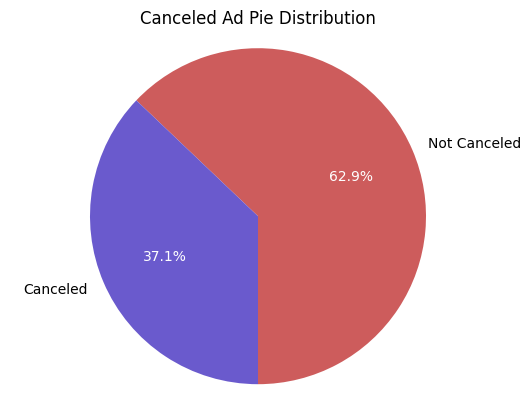

In [ ]:
fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(
    Cancel,
    labels=["Not Canceled", "Canceled"],
    colors=['IndianRed', "SlateBlue"],
    autopct='%1.1f%%',
    startangle=270
)

for text in autotexts:
    text.set_color('white')
    text.set_fontsize(10)

ax.axis('equal')

plt.title('Canceled Ad Pie Distribution')
plt.show()

**63% of bookings resulted in checkout or were not canceled, while the remaining 37% were canceled.**

## Cancel Rates by Months

In [ ]:
df1 = df.copy()

month_canceled = df1.groupby(['arrival_date_month'])['is_canceled'].value_counts().unstack(fill_value=0)

month_canceled.sort_values(by=1, ascending=False, inplace=True)
month_canceled


is_canceled,0,1
arrival_date_month,,
August,5986,3608
May,4947,3256
July,5456,3231
April,4492,3168
June,4500,3126
October,4797,2935
September,4561,2831
March,4502,2170
February,3556,1828


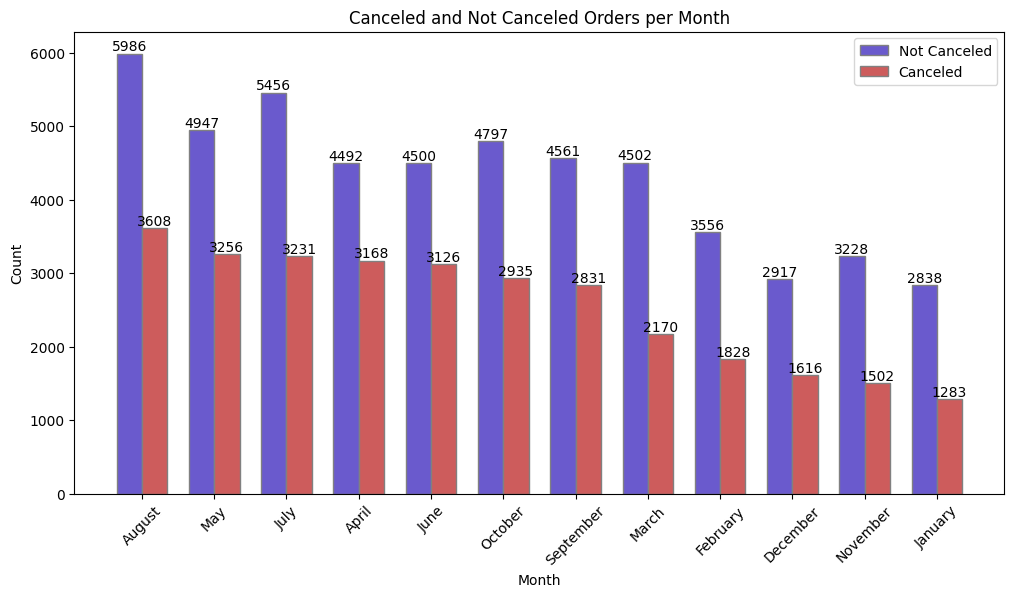

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Define the x-coordinates for the bars
months = month_canceled.index  # Assuming 'month_canceled' is a DataFrame with months as index
not_canceled_counts = month_canceled[0]
canceled_counts = month_canceled[1]
bar_width = 0.35
r1 = np.arange(len(months))
r2 = [x + bar_width for x in r1]

bars1 = ax.bar(r1, not_canceled_counts, color='SlateBlue', width=bar_width, edgecolor='grey', label='Not Canceled')
bars2 = ax.bar(r2, canceled_counts, color='IndianRed', width=bar_width, edgecolor='grey', label='Canceled')

# Add labels and title
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height}', ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height}', ha='center', va='bottom')

ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.set_title('Canceled and Not Canceled Orders per Month')
ax.set_xticks([r + bar_width / 2 for r in r1])
ax.set_xticklabels(months, rotation=45)
ax.legend()

plt.show()

**Insight:** The analysis indicates that August has the highest number of cancellations and bookings, with summer months generally experiencing more cancellations compared to winter months like November and January, which have lower cancellation rates.

**Recommendation:** To minimize cancellations, implement targeted strategies during peak months such as August and other summer periods. Focus on increasing customer commitment and satisfaction during these high-risk times, and use insights from lower cancellation months like November and January to optimize booking strategies and promotions.

## Average Daily Rates of Cancels by Months

In [ ]:
data = df1[df1['is_canceled'] == 1].groupby('arrival_date_month')['adr'].mean().reset_index()
data

,arrival_date_month,adr
0,April,103.604703
1,August,137.098054
2,December,84.959511
3,February,75.570569
4,January,78.216368
5,July,124.346162
6,June,119.871711
7,March,86.559871
8,May,114.216275
9,November,80.941485


<ipython-input-23-a4ca0234c92b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='arrival_date_month', y='adr', data = data, palette=['#cd5c5c'])
<ipython-input-23-a4ca0234c92b>:6: UserWarning: 
The palette list has fewer values (1) than needed (12) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x='arrival_date_month', y='adr', data = data, palette=['#cd5c5c'])


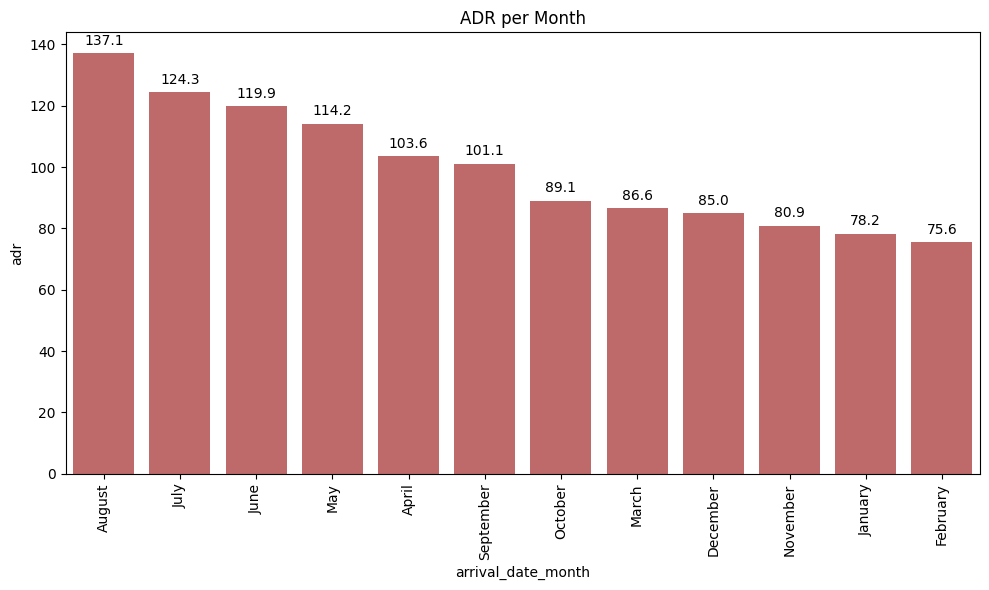

In [ ]:
plt.figure(figsize=(10, 6))

plt.title('ADR per Month')

data.sort_values(by='adr', ascending=False, inplace=True)
ax = sns.barplot(x='arrival_date_month', y='adr', data = data, palette=['#cd5c5c'])


for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Insight:** The analysis shows that August has the highest ADR (137), while July and June also have high ADR values (124 and 119.9, respectively). In contrast, February and January exhibit the lowest ADR (75.6 and 78.2, respectively), with other months showing ADRs ranging between 80.9 and 114.

**Recommendation:** To optimize revenue, consider focusing on strategies to sustain or increase ADR during peak months like August and summer periods. For lower ADR months such as January and February, explore pricing adjustments or promotions to boost revenue and balance ADR throughout the year.

## Lead Time Cancellation Rate

In [ ]:
fig = px.box(df1,x='lead_time',color='is_canceled',title="Cancellation rate based on Lead Time",color_discrete_map={0: 'blue', 1: 'red'})
fig.update_traces(quartilemethod="exclusive")
fig.show()

**Insight:** High lead time is associated with a greater likelihood of cancellation, suggesting that bookings made well in advance are more likely to be canceled compared to those made closer to the arrival date.

**Recommendation:** To reduce cancellations, consider implementing strategies to manage or mitigate risks associated with long lead times. This could include offering incentives for shorter booking windows or refining cancellation policies to address early bookings more effectively.

## Cancellation Rates by Meal Time

<ipython-input-25-ada82d180039>:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




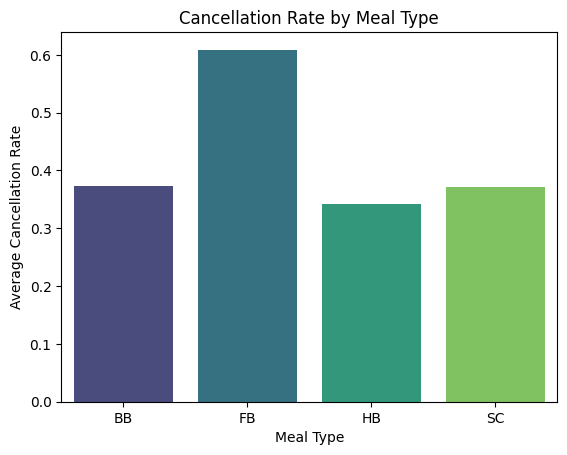

In [ ]:
# Assuming 'df1' is your DataFrame and it has 'meal' and 'is_canceled' columns
meal_cancellation = df1.groupby('meal')['is_canceled'].mean().reset_index()
meal_cancellation.rename(columns={'is_canceled': 'cancellation_rate'}, inplace=True)

# Bar plot for cancellation rate based on meal type
sns.barplot(data=meal_cancellation, x='meal', y='cancellation_rate', palette='viridis')
plt.title('Cancellation Rate by Meal Type')
plt.xlabel('Meal Type')
plt.ylabel('Average Cancellation Rate')
plt.show()

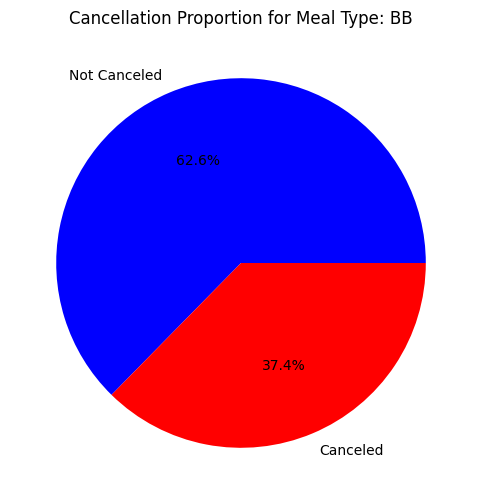

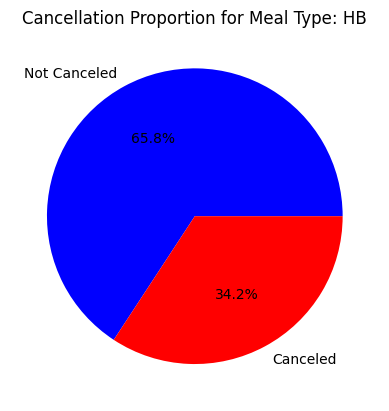

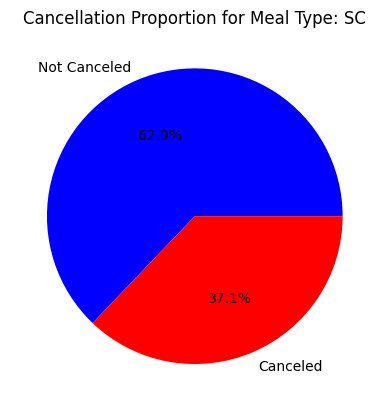

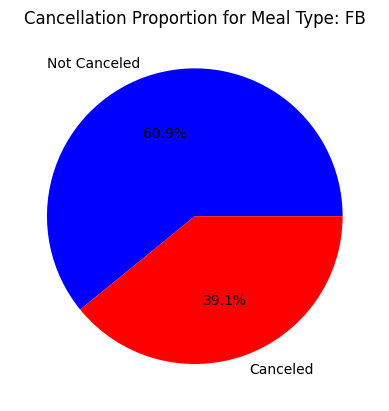

In [ ]:
plt.figure(figsize=(12, 6))

# Pie chart for cancellation proportion by meal type
for meal_type in df['meal'].unique():
    data_pie = df[df['meal'] == meal_type]['is_canceled'].value_counts()
    plt.pie(data_pie, labels=['Not Canceled', 'Canceled'], autopct='%1.1f%%', colors=['blue', 'red'])
    plt.title(f'Cancellation Proportion for Meal Type: {meal_type}')
    plt.show()

**Insight:** Bookings with a Full Board meal package have the highest cancellation rate, while Half Board has the lowest.

**Recommendation:** To reduce cancellations, improve the attractiveness and flexibility of Full Board packages by offering incentives or more flexible terms, while promoting the benefits of Half Board options to attract more bookings.

## Impact of Market Segments Cancellation Rates

In [ ]:
# Create pivot table for cancellations by market segment
pivot_segment = df.pivot_table(index='market_segment', columns='is_canceled', aggfunc='size', fill_value=0)
pivot_segment['Total'] = pivot_segment[0] + pivot_segment[1]
pivot_segment['Cancellation Rate (%)'] = (pivot_segment[1] / pivot_segment['Total']) * 100

print("Pivot Table for Market Segment:")
print(pivot_segment)

Pivot Table for Market Segment:
is_canceled         0      1  Total  Cancellation Rate (%)
market_segment                                            
Aviation          120     40    160              25.000000
Complementary     452     57    509              11.198428
Corporate        2982    704   3686              19.099295
Direct           7337   1337   8674              15.413881
Groups           5019   8188  13207              61.997426
Offline TA/TO   10930   5782  16712              34.597894
Online TA       24940  14446  39386              36.678007


<ipython-input-28-8ccfc9dfefbc>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




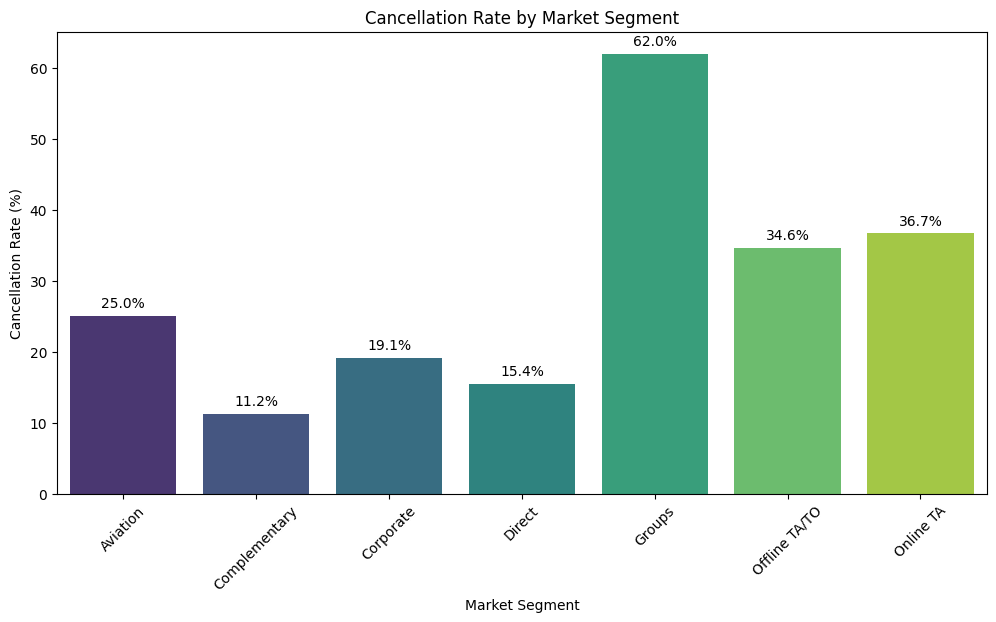

In [ ]:
# Plot cancellation rates by market segment
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=pivot_segment.index, y=pivot_segment['Cancellation Rate (%)'], palette='viridis')
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)

# Add numerical labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

**Insight:** The "Groups" segment experiences the highest cancellation rate at 60.7%, while both "Online TA" and "Offline TA/TO" also have high cancellation rates, suggesting that group bookings and those made through travel agents are more likely to be canceled.

**Recommendation:** To mitigate cancellations, consider implementing stricter cancellation policies for group bookings and enhancing follow-up procedures for reservations made through travel agents. Additionally, explore offering incentives or more flexible terms to reduce the likelihood of cancellations in these high-risk segments.

## Cancellation Rates by Family Type

In [ ]:
# Define a function to categorize family type
def categorize_family(row):
    if row['adults'] == 0 and row['children'] == 0 and row['babies'] == 0:
        return 'No Guests'
    elif row['adults'] > 0 and row['children'] == 0 and row['babies'] == 0:
        return 'Single/Couple'
    elif row['adults'] > 0 and (row['children'] > 0 or row['babies'] > 0):
        return 'Family with Children'
    else:
        return 'Other'

In [ ]:
df['family'] = df.apply(categorize_family, axis=1)

In [ ]:
# Group by 'family' and calculate the cancellation rate
family_cancellation = df.groupby('family')['is_canceled'].mean() * 100
family_cancellation = family_cancellation.reset_index()
family_cancellation.columns = ['Family Type', 'Cancellation Rate (%)']


<ipython-input-32-0c52e7f4783e>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




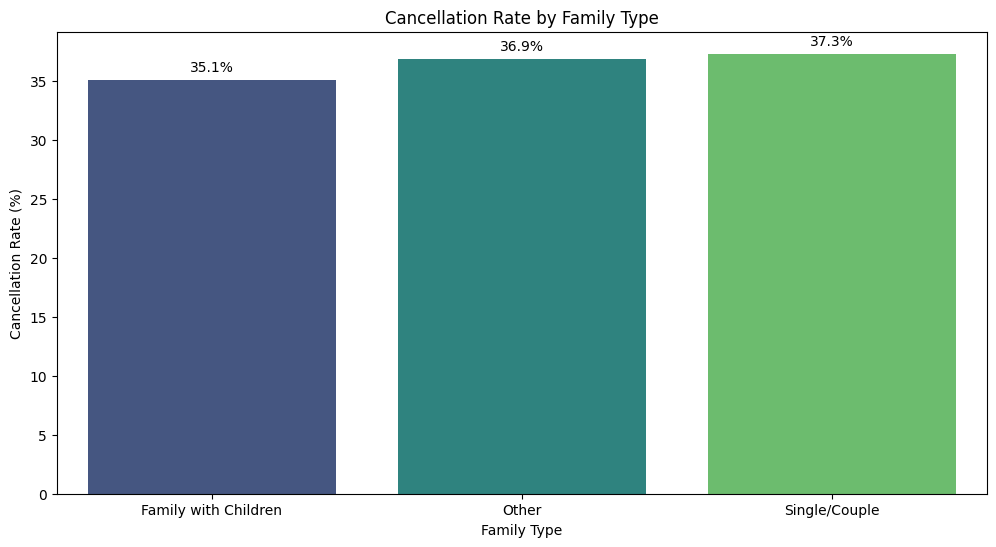

In [ ]:
# Plot the cancellation rate by family type
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Family Type', y='Cancellation Rate (%)', data=family_cancellation, palette='viridis')
plt.title('Cancellation Rate by Family Type')
plt.xlabel('Family Type')
plt.ylabel('Cancellation Rate (%)')

# Add labels to each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

**Insight:** Among family types, "Family with Children" has a cancellation rate of 35.1%, "Other" has a rate of 36.9%, and "Single/Couple" has the highest rate at 37.3%, indicating that cancellations are more prevalent among single or couple bookings compared to families with children.

**Recommendation:** To address higher cancellation rates, consider tailoring booking policies and incentives to better cater to the needs of "Single/Couple" guests, and potentially provide special offers or guarantees to reduce cancellations among this group.

## Reserved Room vs Assigned Room

In [ ]:
df1 = df.copy()


In [ ]:
df1['is_room_matching'] = df1['reserved_room_type'] == df1['assigned_room_type']
room_cancellations = df1.groupby(['is_room_matching'])['is_canceled'].value_counts().unstack(fill_value=0)
room_cancellations.columns = ['Checkout', 'Canceled']
room_cancellations

,Checkout,Canceled
is_room_matching,,
False,9638,553
True,42142,30001


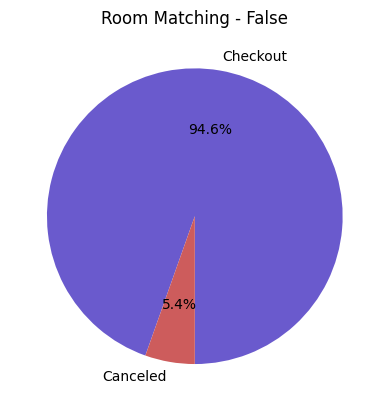

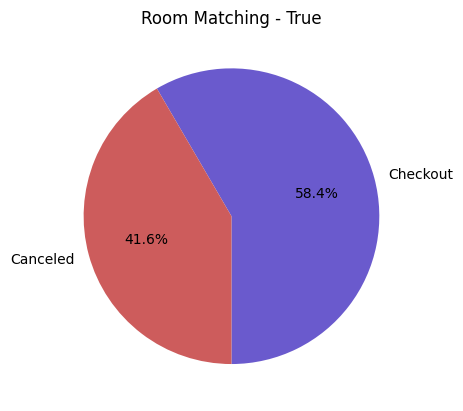

In [ ]:
for index, row in room_cancellations.iterrows():
    data = [row['Checkout'], row['Canceled']]
    fig, ax = plt.subplots()
    plt.title('Room Matching - '+str(index))
    wedges, texts, autotexts = ax.pie(data, labels=['Checkout', 'Canceled'], autopct='%1.1f%%', startangle=270, colors=['SlateBlue', "IndianRed"],)

**Insight:** Bookings with correct room matching have a significantly higher cancellation rate (41.5%) compared to those with incorrect room matching (5.5%), suggesting that accurate room matching is strongly associated with lower cancellation rates.

**Recommendation:** Improve the accuracy of room matching to reduce the likelihood of cancellations. Consider implementing a robust room allocation system or providing additional incentives for guests to confirm room preferences to enhance overall booking stability.

## Reservation Status Date

In [ ]:
def categorize_day(timestamp):
    if timestamp.weekday() < 5:
        return 'Weekday'
    else:
        return 'Weekend'

month_mapping = {
    'January': '1',
    'February': '2',
    'March': '3',
    'April': '4',
    'May': '5',
    'June': '6',
    'July': '7',
    'August': '8',
    'September': '9',
    'October': '10',
    'November': '11',
    'December': '12'
}

df_dummy = df1.copy()
df_dummy['reservation_status_date'] = pd.to_datetime(df_dummy['reservation_status_date'])
df_dummy['day_category'] = df_dummy['reservation_status_date'].apply(categorize_day)
df_dummy['day_category']
df_dummy

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID,family,is_room_matching,day_category
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,...,Transient,38.40,0,0,Check-Out,2019-01-14,1,Single/Couple,True,Weekday
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,...,Transient,62.80,0,0,Canceled,2017-10-21,2,Single/Couple,True,Weekend
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,...,Transient,110.00,0,0,Canceled,2018-11-25,3,Single/Couple,True,Weekend
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,...,Transient,45.00,0,0,Check-Out,2018-10-18,4,Single/Couple,True,Weekday
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,...,Transient,57.92,0,1,Canceled,2017-08-24,5,Single/Couple,True,Weekday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83288,"Crystal Cove, Barbados Barbados",0,4,2018,October,44,25,0,2,2,...,Transient,169.00,1,1,Check-Out,2018-10-27,83289,Family with Children,True,Weekend
83289,"Berlin Marriott Hotel Berlin, Germany",0,30,2017,September,38,14,1,3,2,...,Transient,94.50,0,2,Check-Out,2017-09-18,83290,Single/Couple,True,Weekday
83290,"The Ritz-Carlton, Tokyo Tokyo, Japan",0,165,2019,June,25,21,4,10,2,...,Transient,123.50,0,1,Check-Out,2019-07-05,83291,Single/Couple,True,Weekday
83291,"Colony Club, Barbados Barbados",0,180,2018,July,32,31,2,4,2,...,Transient,122.25,0,1,Check-Out,2018-08-06,83292,Family with Children,False,Weekday


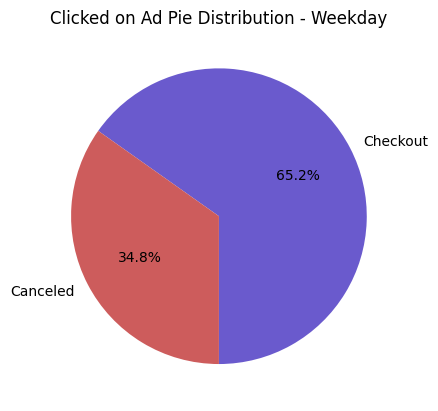

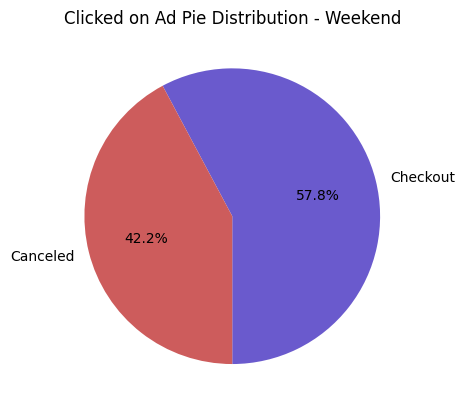

In [ ]:
day_cat = df_dummy.groupby(['day_category', 'is_canceled']).size().unstack(fill_value=0)
day_cat.columns = ['Checkout', 'Canceled']
day_cat
for index, row in day_cat.iterrows():
    data = [row['Checkout'], row['Canceled']]
    fig, ax = plt.subplots()
    plt.title('Clicked on Ad Pie Distribution - '+index)
    wedges, texts, autotexts = ax.pie(data, labels=['Checkout', 'Canceled'], autopct='%1.1f%%', startangle=270, colors=['SlateBlue', "IndianRed"],)

**Insight:** Bookings made on weekends have a higher cancellation rate (42.2%) compared to those made on weekdays (34.8%), indicating that weekends are more prone to cancellations.

**Recommendation:** Implement strategies to reduce cancellations for weekend bookings, such as offering incentives or flexible policies to encourage commitment, and consider analyzing and addressing specific factors that might be influencing higher cancellation rates on weekends.

## Cancelation per Country

In [ ]:
#Continents data
country_df = pd.read_csv("country-code.csv")
country_df = country_df.rename(columns={'alpha-3': 'country', 'name': 'country_name'})
country_df = country_df[['country', 'country_name']]

country_df.info()

df_merged = pd.merge(df_dummy, country_df, on='country', how='left')
df_merged.fillna("Unspecified", inplace=True)
df = df_merged.drop(columns=['country'])
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country       249 non-null    object
 1   country_name  249 non-null    object
dtypes: object(2)
memory usage: 4.0+ KB


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID,family,is_room_matching,day_category,country_name
0,"Crystal Cove, Barbados Barbados",0,8,2019,January,2,10,0,4,2,...,38.40,0,0,Check-Out,2019-01-14,1,Single/Couple,True,Weekday,Italy
1,"Greensboro Courtyard Greensboro, NC",1,524,2018,December,51,15,0,2,2,...,62.80,0,0,Canceled,2017-10-21,2,Single/Couple,True,Weekend,Portugal
2,"The Westin Peachtree Plaza, Atlanta Atlanta, GA",1,175,2019,May,20,19,1,2,2,...,110.00,0,0,Canceled,2018-11-25,3,Single/Couple,True,Weekend,Portugal
3,Courtyard by Marriott Aberdeen Airport Aberdee...,0,0,2018,October,43,17,1,0,1,...,45.00,0,0,Check-Out,2018-10-18,4,Single/Couple,True,Weekday,Portugal
4,"W New York – Union Square New York, NY",1,33,2017,September,39,26,2,3,2,...,57.92,0,1,Canceled,2017-08-24,5,Single/Couple,True,Weekday,Portugal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82329,"Crystal Cove, Barbados Barbados",0,4,2018,October,44,25,0,2,2,...,169.00,1,1,Check-Out,2018-10-27,83289,Family with Children,True,Weekend,France
82330,"Berlin Marriott Hotel Berlin, Germany",0,30,2017,September,38,14,1,3,2,...,94.50,0,2,Check-Out,2017-09-18,83290,Single/Couple,True,Weekday,Switzerland
82331,"The Ritz-Carlton, Tokyo Tokyo, Japan",0,165,2019,June,25,21,4,10,2,...,123.50,0,1,Check-Out,2019-07-05,83291,Single/Couple,True,Weekday,Ireland
82332,"Colony Club, Barbados Barbados",0,180,2018,July,32,31,2,4,2,...,122.25,0,1,Check-Out,2018-08-06,83292,Family with Children,False,Weekday,Germany


In [ ]:
country_count = df.groupby(['country_name'])['is_canceled'].value_counts().unstack(fill_value=0)

country_count.columns = ['Checkout', 'Canceled']

country_count = country_count.reset_index()

country_count.sort_values(by='Canceled', ascending=False, inplace=True)


##Limit head to 20 to visualize the graph
fig = px.bar(country_count.head(20), x='country_name', y=['Checkout', 'Canceled'], text_auto=True, color_discrete_map={'Checkout': 'SlateBlue', 'Canceled': 'IndianRed'})
fig.update_traces(marker_line_width=1,marker_line_color="white")

fig.show()
country_count

,country_name,Checkout,Canceled
119,Portugal,14703,18997
154,United Kingdom of Great Britain and Northern I...,6670,1692
137,Spain,4173,1512
50,France,5847,1327
70,Italy,1682,918
...,...,...,...
67,Iraq,11,0
131,Seychelles,1,0
132,Sierra Leone,1,0
103,Namibia,1,0


Portugal has the highest number of cancellations with 19,212, while 15,086 bookings ended in checkout.

# Feature Engineering

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82334 entries, 0 to 82333
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           82334 non-null  object        
 1   is_canceled                     82334 non-null  int64         
 2   lead_time                       82334 non-null  int64         
 3   arrival_date_year               82334 non-null  int64         
 4   arrival_date_month              82334 non-null  object        
 5   arrival_date_week_number        82334 non-null  int64         
 6   arrival_date_day_of_month       82334 non-null  int64         
 7   stays_in_weekend_nights         82334 non-null  int64         
 8   stays_in_week_nights            82334 non-null  int64         
 9   adults                          82334 non-null  int64         
 10  children                        82334 non-null  int64         
 11  ba

Created new columns for day_category that categorizes if reservation is done on a weekend or a weekday.

And another column called is_room_matching, it categorizes the data of reserved_room_type and assigned_room_type if they have similar values.

and lastly a column called family, where it categorizes the data of family to groups such as Single/Couple, Family / With Children, and Other for groups that fall no category between the two.

# MACHINE LEARNING MODELING

## Label Encoding

In [ ]:
text_data_features = [i for i in list(df.columns) if i not in list(df.describe().columns)]

le = LabelEncoder()

for col in text_data_features:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,bookingID,family,is_room_matching,day_category,country_name
0,14,0,8,2019,4,2,10,0,4,2,...,38.40,0,0,1,2019-01-14,1,2,True,0,70
1,18,1,524,2018,2,51,15,0,2,2,...,62.80,0,0,0,2017-10-21,2,2,True,1,119
2,56,1,175,2019,8,20,19,1,2,2,...,110.00,0,0,0,2018-11-25,3,2,True,1,119
3,10,0,0,2018,10,43,17,1,0,1,...,45.00,0,0,1,2018-10-18,4,2,True,0,119
4,62,1,33,2017,11,39,26,2,3,2,...,57.92,0,1,0,2017-08-24,5,2,True,0,119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82329,14,0,4,2018,10,44,25,0,2,2,...,169.00,1,1,1,2018-10-27,83289,0,True,1,50
82330,5,0,30,2017,11,38,14,1,3,2,...,94.50,0,2,1,2017-09-18,83290,2,True,0,142
82331,54,0,165,2019,6,25,21,4,10,2,...,123.50,0,1,1,2019-07-05,83291,2,True,0,68
82332,8,0,180,2018,5,32,31,2,4,2,...,122.25,0,1,1,2018-08-06,83292,0,False,0,53


## Feature Selection

In [ ]:
X = df.drop(['hotel', 'bookingID', 'reservation_status_date', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'is_canceled', 'reservation_status', 'adults', 'children', 'babies'], axis=1)
y = df['is_canceled']

## Data Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

### Handling Imbalance

In [ ]:
# Identify columns with 'object' dtype (likely containing strings)
object_cols = X_train.select_dtypes(include=['object']).columns

# Apply Label Encoding to convert string columns to numerical
label_encoder = LabelEncoder()
for col in object_cols:
    # Check if the column contains both strings and numbers
    if X_train[col].apply(type).nunique() > 1:
        # Handle mixed types (example: convert numbers to strings)
        X_train[col] = X_train[col].astype(str)
    X_train[col] = label_encoder.fit_transform(X_train[col])

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

## Data Train

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression(random_state=42)

In [ ]:
y_train_pred_log_reg = log_reg.predict(X_train)
y_test_pred_log_reg = log_reg.predict(X_test)

### LightGBM

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 21388, number of negative: 36245
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1152
[LightGBM] [Info] Number of data points in the train set: 57633, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.371107 -> initscore=-0.527471
[LightGBM] [Info] Start training from score -0.527471


LGBMClassifier(random_state=42)

In [ ]:
y_train_pred_lgbm = lgbm.predict(X_train)
y_test_pred_lgbm = lgbm.predict(X_test)

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_train_pred_random_forest = random_forest.predict(X_train)
y_test_pred_random_forest = random_forest.predict(X_test)

### SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:
y_train_pred_svc = svm_model.predict(X_train)
y_test_pred_svc = svm_model.predict(X_test)

### XGBoost

In [ ]:
from xgboost import XGBClassifier

xgboost = XGBClassifier(random_state=42)
xgboost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_train_pred_xgboost = xgboost.predict(X_train)
y_test_pred_xgboost = xgboost.predict(X_test)

### Model Evaluation

In [ ]:
# Evaluasi Logistic Regression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

print('Akurasi Logistic Regression:', accuracy_score(y_test, y_test_pred_log_reg))
print('F1 Score Logistic Regression:', f1_score(y_test, y_test_pred_log_reg))
print('Precision Logistic Regression:', precision_score(y_test, y_test_pred_log_reg))
print('Recall Logistic Regression:', recall_score(y_test, y_test_pred_log_reg))
print('AUC Logistic Regression:', roc_auc_score(y_test, y_test_pred_log_reg))

# Evaluasi SVM
print('\nAkurasi SVM:', accuracy_score(y_test, y_test_pred_svc))
print('F1 Score SVM:', f1_score(y_test, y_test_pred_svc))
print('Precision SVM:', precision_score(y_test, y_test_pred_svc))
print('Recall SVM:', recall_score(y_test, y_test_pred_svc))
print('AUC SVM:', roc_auc_score(y_test, y_test_pred_svc))

# Evaluasi Random Forest
print('\nAkurasi Random Forest:', accuracy_score(y_test, y_test_pred_random_forest))
print('F1 Score Random Forest:', f1_score(y_test, y_test_pred_random_forest))
print('Precision Random Forest:', precision_score(y_test, y_test_pred_random_forest))
print('Recall Random Forest:', recall_score(y_test, y_test_pred_random_forest))
print('AUC Random Forest:', roc_auc_score(y_test, y_test_pred_random_forest))

# Evaluasi XGBoost
print('\nAkurasi XGBoost:', accuracy_score(y_test, y_test_pred_xgboost))
print('F1 Score XGBoost:', f1_score(y_test, y_test_pred_xgboost))
print('Precision XGBoost:', precision_score(y_test, y_test_pred_xgboost))
print('Recall XGBoost:', recall_score(y_test, y_test_pred_xgboost))
print('AUC XGBoost:', roc_auc_score(y_test, y_test_pred_xgboost))

# Evaluasi LightGBM
print('\nAkurasi LightGBM:', accuracy_score(y_test, y_test_pred_lgbm))
print('F1 Score LightGBM:', f1_score(y_test, y_test_pred_lgbm))
print('Precision LightGBM:', precision_score(y_test, y_test_pred_lgbm))
print('Recall LightGBM:', recall_score(y_test, y_test_pred_lgbm))
print('AUC LightGBM:', roc_auc_score(y_test, y_test_pred_lgbm))

Akurasi Logistic Regression: 0.7297680255860086
F1 Score Logistic Regression: 0.5765399987312059
Precision Logistic Regression: 0.6887979384568743
Recall Logistic Regression: 0.49574514510146195
AUC Logistic Regression: 0.6817959713276863

Akurasi SVM: 0.6681915711914498
F1 Score SVM: 0.3386055519690123
Precision SVM: 0.6503409795412275
Recall SVM: 0.22888937377263802
AUC SVM: 0.5781395694096534

Akurasi Random Forest: 0.8915428525160924
F1 Score Random Forest: 0.8466601797264038
Precision Random Forest: 0.8905478627332932
Recall Random Forest: 0.8068950469125027
AUC Random Forest: 0.8741910059152149

Akurasi XGBoost: 0.8865632970325088
F1 Score XGBoost: 0.8437081659973226
Precision XGBoost: 0.8631590960967815
Recall XGBoost: 0.8251145537857298
AUC XGBoost: 0.8739669968799908

Akurasi LightGBM: 0.8796809845755232
F1 Score LightGBM: 0.8329210703845288
Precision LightGBM: 0.8591974019948968
Recall LightGBM: 0.8082042330351298
AUC LightGBM: 0.8650290556871819


Random Forest is the best-performing model based on the evaluation results, demonstrating superior performance in terms of accuracy, F1 Score, Precision, Recall, and AUC compared to the other models

# Hyperparameter tuning

## Initial Tuning
Focus on the basic parameter ranges to filter for more promising parameters.

In [ ]:
param_grid_rf_initial = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
}

In [ ]:
grid_search_rf_initial = GridSearchCV(estimator=random_forest, param_grid=param_grid_rf_initial,
                                       cv=5, scoring='accuracy', n_jobs=-1)

In [ ]:
grid_search_rf_initial.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10], 'n_estimators': [50, 100]},
             scoring='accuracy')

In [ ]:
best_rf_initial = grid_search_rf_initial.best_estimator_
best_rf_initial_hyperparams = grid_search_rf_initial.best_params_

print("Best hyperparameters from initial search: ", best_rf_initial_hyperparams)

Best hyperparameters from initial search:  {'max_depth': None, 'n_estimators': 100}


In [ ]:
param_grid_rf_final = {
    'n_estimators': [best_rf_initial_hyperparams['n_estimators'], 150, 200],
    'max_depth': [best_rf_initial_hyperparams['max_depth'], 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
grid_search_rf_final = GridSearchCV(estimator=best_rf_initial, param_grid=param_grid_rf_final,
                                     cv=5, scoring='accuracy', n_jobs=-1)

In [ ]:
grid_search_rf_final.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 150, 200]},
             scoring='accuracy')

In [ ]:
best_rf = grid_search_rf_final.best_estimator_
best_rf_hyperparams = grid_search_rf_final.best_params_

print("Best hyperparameters from final tuning: ", best_rf_hyperparams)

Best hyperparameters from final tuning:  {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


## 2. Final Tuning
Use the results from the initial tuning to perform a more detailed and specific parameter search

In [ ]:
y_train_pred_random_forest = best_rf.predict(X_train)
y_test_pred_random_forest = best_rf.predict(X_test)


In [ ]:
accuracy = accuracy_score(y_test, y_test_pred_random_forest)
f1 = f1_score(y_test, y_test_pred_random_forest)
precision = precision_score(y_test, y_test_pred_random_forest)
recall = recall_score(y_test, y_test_pred_random_forest)
auc = roc_auc_score(y_test, y_test_pred_random_forest)

In [ ]:
print('\nAkurasi Random Forest:', accuracy)
print('F1 Score Random Forest:', f1)
print('Precision Random Forest:', precision)
print('Recall Random Forest:', recall)
print('AUC Random Forest:', auc)


Akurasi Random Forest: 0.892231083761791
F1 Score Random Forest: 0.8480246631651063
Precision Random Forest: 0.8894610778443114
Recall Random Forest: 0.8102771110626228
AUC Random Forest: 0.8754314425606001


The evaluation of our Random Forest (RF) model on the test data is as follows
1. Accuracy: 89.22%
  The model correctly predicts cancellations 89% of the time, indicating strong overall performance.
2. Precision (for cancellations): 88.95%
  About 89% of predicted cancellations are accurate, showing high precision.
3. Recall (for cancellations): 81.03%
  The model identifies 81% of actual cancellations, reflecting good recall.
4. F1 Score (for cancellations): 84.80%
  Balances Precision and Recall well with an F1 Score of 84.80%.
5. AUC: 87.54%
The model shows excellent ability to differentiate between cancellations and non-cancellations.

**Conclusion:** The RandomForestClassifier performs very well, with high accuracy, strong precision, good recall, balanced F1 Score, and excellent AUC.

# Evaluation

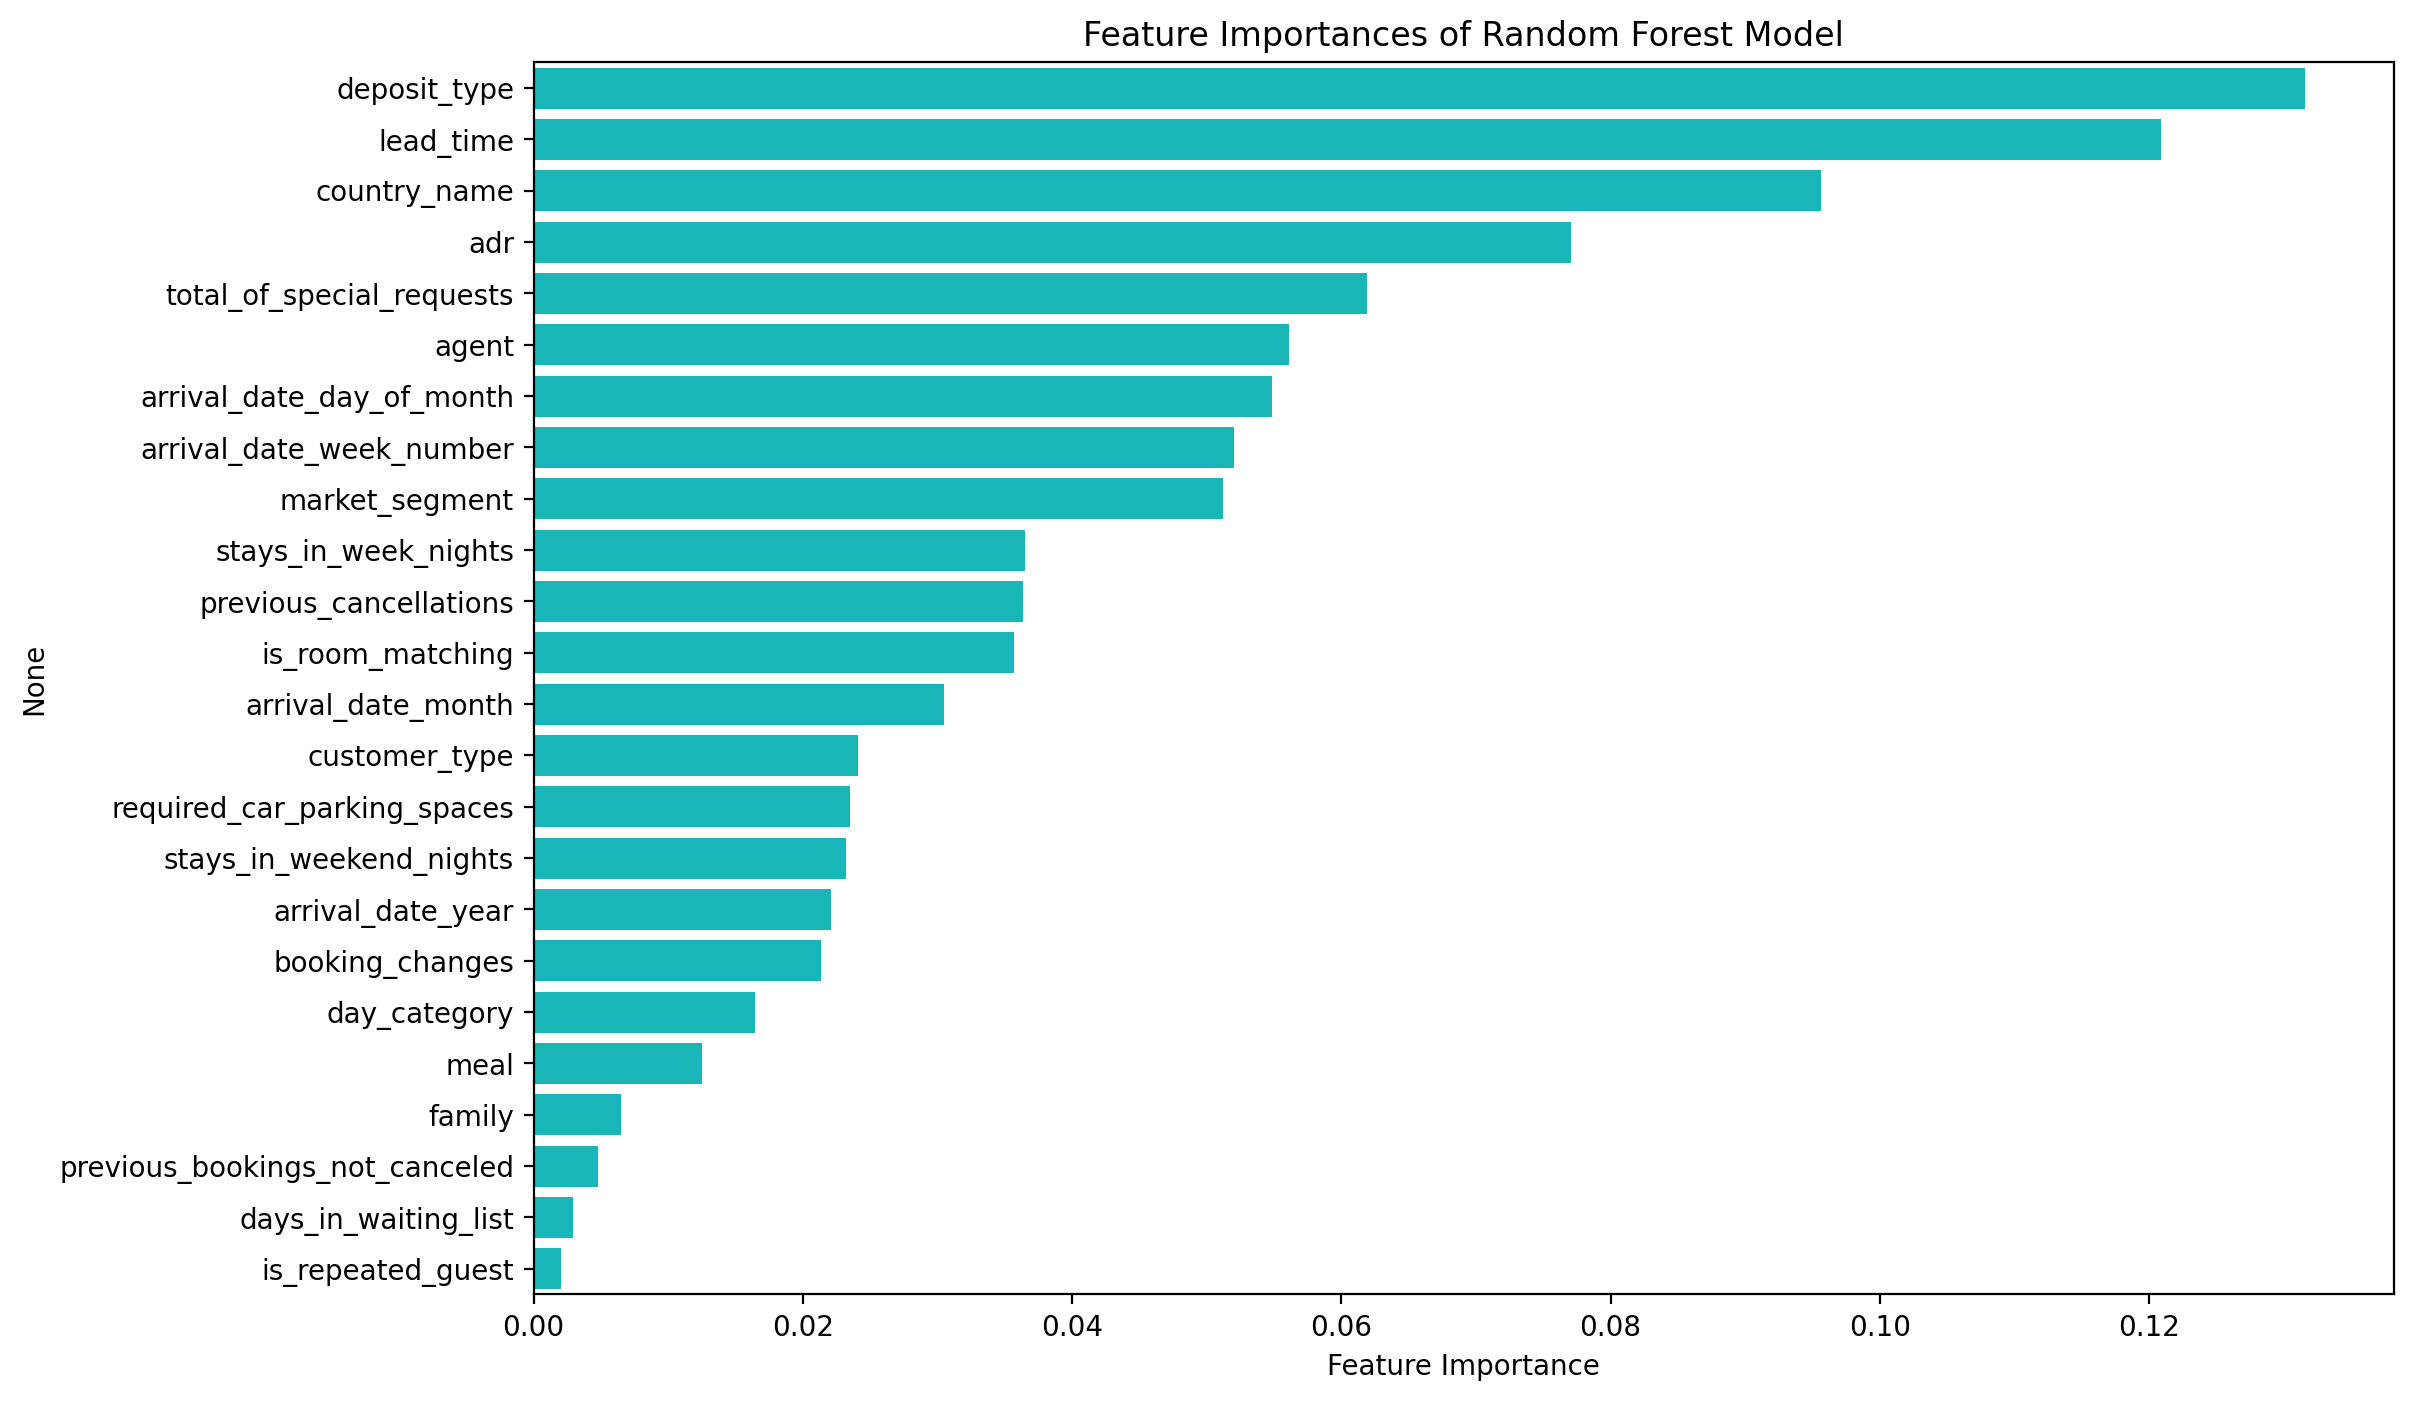

In [ ]:
feature_importances = best_rf.feature_importances_

sorted_indices = np.argsort(feature_importances)[::-1]

plt.figure(figsize=(12, 8), dpi=200)
sns.barplot(x=feature_importances[sorted_indices], y=X.columns[sorted_indices], color='darkturquoise')
plt.xlabel('Feature Importance')
plt.title('Feature Importances of Random Forest Model')
plt.yticks(fontsize=10)
plt.show()

The Random Forest model has identified that features related to deposit type, lead time, country name, average daily rate (ADR), total special request, and agent are the most important for predicting cancellations. This indicates that factors such as booking details, financial aspects, and the booking source are particularly significant in determining whether a booking will be canceled